<a href="https://colab.research.google.com/github/yejxjj/2026-1_CV/blob/main/CV_HW%232.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [3]:
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0309(a)(washed_out_aerial_image).tif"
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0310(b)(washed_out_pollen_image).tif"
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/school.jpg"
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/finger.jpg"
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0905(a)(wirebond-mask).tif"
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0939(a)(headCT-Vandy).tif"
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0938(a)(cygnusloop_Xray_original).tif"
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0940(a)(rice_image_with_intensity_gradient).tif"
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0943(a)(dark_blobs_on_light_background).tif"

--2026-04-11 14:45:40--  https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0309(a)(washed_out_aerial_image).tif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 589115 (575K) [image/tiff]
Saving to: ‘Fig0309(a)(washed_out_aerial_image).tif’

Fig0309(a)(washed_o 100%[===================>] 575.31K  --.-KB/s    in 0.03s   

2026-04-11 14:45:40 (16.1 MB/s) - ‘Fig0309(a)(washed_out_aerial_image).tif’ saved [589115/589115]

--2026-04-11 14:45:40--  https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0310(b)(washed_out_pollen_image).tif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... con

# HW#2-1


In [4]:
img = cv2.imread('Fig0309(a)(washed_out_aerial_image).tif', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, dsize=(0,0), fx=0.5, fy=0.5)


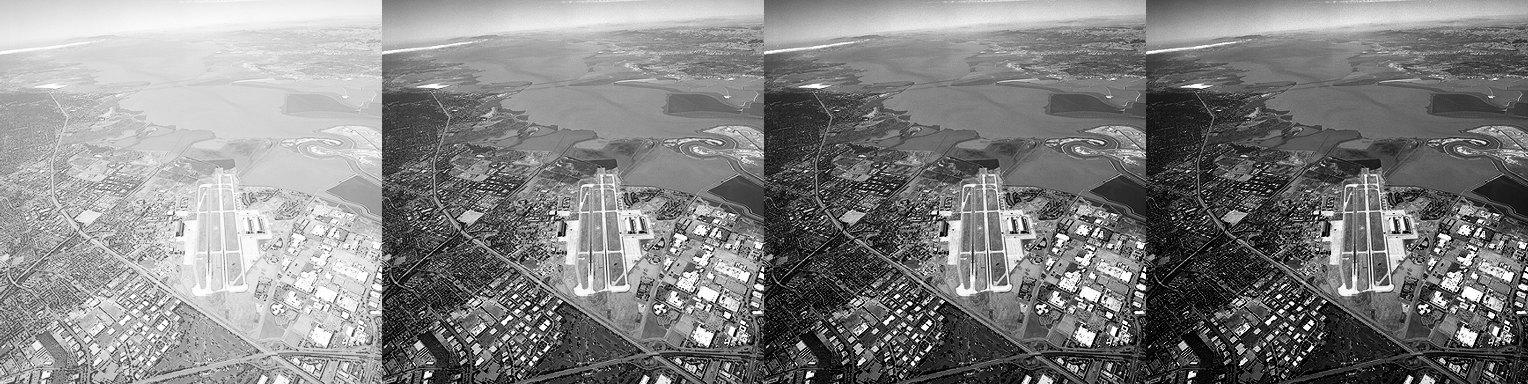

In [5]:

# 감마 연산
def gamma_op(f, gamma_val=1.0):
    f1 = f / 255.0  # 정규화
    return np.uint8(255 * (f1 ** gamma_val))

gc = np.hstack((
    gamma_op(img, 1.0),
    gamma_op(img, 3.0),
    gamma_op(img, 4.0),
    gamma_op(img, 5.0),
))

cv2_imshow(gc)

$\gamma = 1.0$ (원본): 전체적으로 밝기가 높고 대비가 낮아 지형지물이 뚜렷하게 보이지 않음.

$\gamma = 3.0 \sim 5.0$: 감마 값이 커질수록 영상의 전반적인 밝기는 낮아지지만, 밝은 영역에 뭉쳐있던 데이터들이 넓게 펼쳐지면서 경계가 훨씬 선명하게 보임.

밝은 영상의 품질 개선을 위해서는 감마 보정을 적용하여 대비를 높이는 것이 효과적이다.

# HW#2-2

In [6]:
img = cv2.imread('Fig0310(b)(washed_out_pollen_image).tif', 0)
img = cv2.resize(img, dsize=(0,0), fx=0.5, fy=0.5)


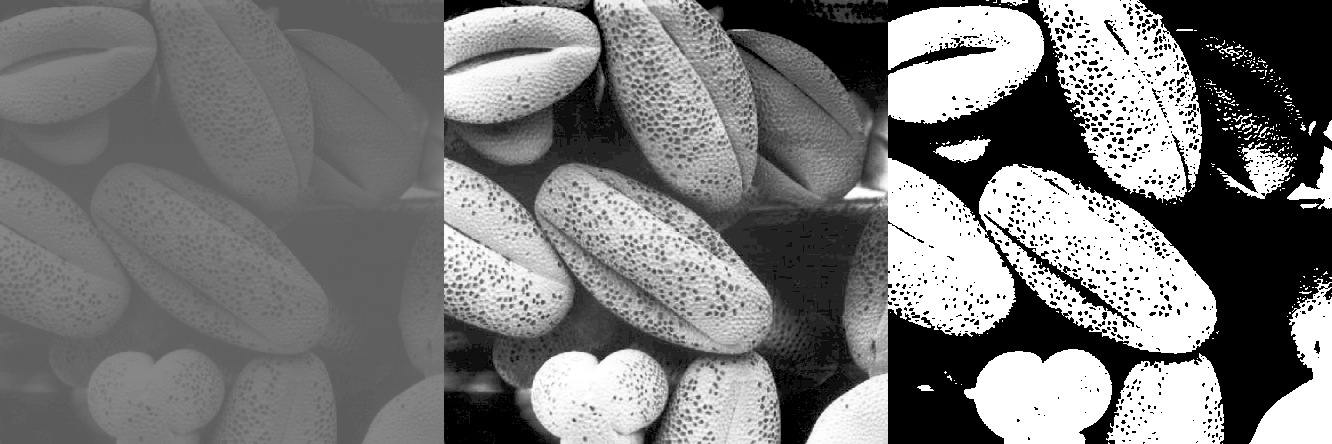

In [7]:

# 히스토그램 평활화
equalized_img = cv2.equalizeHist(img)

# Otsu 이진화
# 평활화된 이미지를 사용해서 배경과 물체를 정확하게 분리
t, bin_img = cv2.threshold(equalized_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

result_show = np.hstack((img, equalized_img, bin_img))
cv2_imshow(result_show)

1. 대비 개선: 원본 영상에 히스토그램 평활화를 적용해서 좁게 몰려있던 밝기 분포를 전체 구간으로 확장한다.
2. 임계값 찾기: 오츄 알고리즘을 실행해서 배경과 객체를 깔끔하게 분리할 수 있는 최적의 임계값을 자동으로 찾아낸다.
3. 흑백 분리: 찾아낸 임계값을 기준으로 이진화함

#HW#2-3

In [8]:
img = cv2.imread('Fig0310(b)(washed_out_pollen_image).tif', 0)
img = cv2.imread('Fig0309(a)(washed_out_aerial_image).tif', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (300, 300))


원본 | Box 블러 | 가우시안 블러


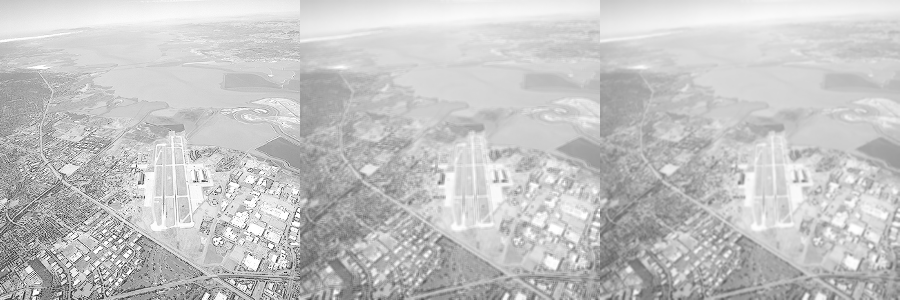

라플라시안(4) | 라플라시안(8) | 엠보싱


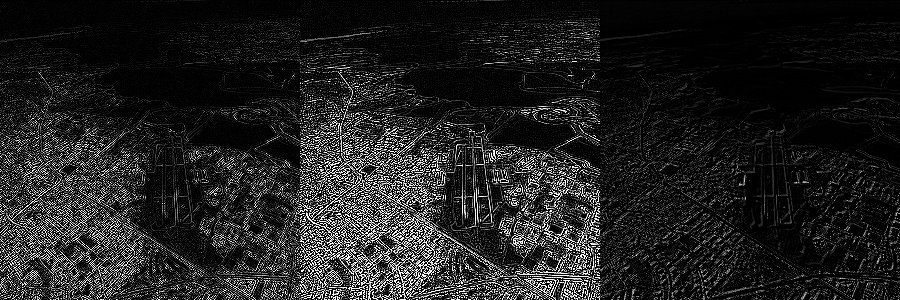

In [9]:

# Box Filter - 블러링
Box = np.ones((3,3), np.float32) / 9

# Gaussian Filter - 부드러운 블러링
Gaussian = np.array([
    [0.0030, 0.0133, 0.0219, 0.0133, 0.0030],
    [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
    [0.0219, 0.0983, 0.1621, 0.0983, 0.0219],
    [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
    [0.0030, 0.0133, 0.0219, 0.0133, 0.0030]
])

# Laplacian - 에지 검출
Laplacian1 = np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]])

# Laplacian - 더 강한 에지 검출
Laplacian2 = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])

# Embossing - 입체감 효과
Embossing = np.array([[-1, 0, 0], [0, 0, 0], [0, 0, 1]])

# 3. 컨볼루션 연산 적용
res_box = cv2.filter2D(img, -1, Box)
res_gauss = cv2.filter2D(img, -1, Gaussian)
res_lap1 = cv2.filter2D(img, -1, Laplacian1)
res_lap2 = cv2.filter2D(img, -1, Laplacian2)
res_emboss = cv2.filter2D(img, -1, Embossing)

print("원본 | Box 블러 | 가우시안 블러")
cv2_imshow(np.hstack((img, res_box, res_gauss)))
print("라플라시안(4) | 라플라시안(8) | 엠보싱")
cv2_imshow(np.hstack((res_lap1, res_lap2, res_emboss)))

Box Filter: 모든 가중치가 동일한 평균값 필터
-> 주변 픽셀값을 평균내어 영상을 블러 처리

Gaussian: 중심부가 높고 외곽이 낮은 가중치
-> 박스 필터보다 자연스럽게 블러링 효과가 나타남. 인접 픽셀의 영향을 더 많이 받

Laplacian(4,8): 중심과 주변의 차이를 극대화
-> 에지를 검출, 주변과 밝기 차이가 큰 부분을 흰색으로 표시.

Embossing: 대각선 방향으로 가중치 차이
-> 영상에 입체감을 주며, 특정 방향의 경계선을 강조

#HW#2-4

In [10]:
img = cv2.imread('school.jpg', 0)
img = cv2.resize(img, (500, 350))

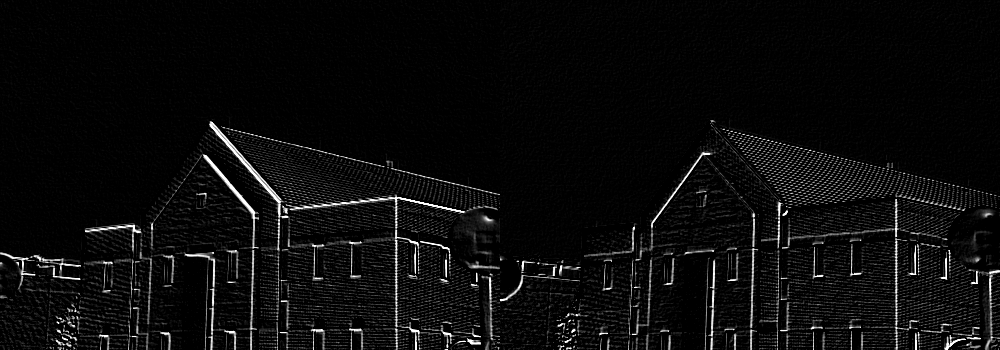

In [11]:
#대각선 소벨 마스크 정의
# 45도 방향 에지 검출 마스크
kernel_45 = np.array([
    [ 0,  1,  2],
    [-1,  0,  1],
    [-2, -1,  0]
])

# -45도 방향 에지 검출 마스크
kernel_neg45 = np.array([
    [-2, -1,  0],
    [-1,  0,  1],
    [ 0,  1,  2]
])

# 컨볼루션 연산
edge_45 = cv2.filter2D(img, -1, kernel_45)
edge_neg45 = cv2.filter2D(img, -1, kernel_neg45)

edge_total = cv2.addWeighted(edge_45, 0.5, edge_neg45, 0.5, 0)

cv2_imshow(np.hstack((edge_45, edge_neg45)))

소벨 연산자의 마스크 계수를 조정함으로써 특정 방향(대각선)의 고주파 성분만을 선택적으로 추출할 수 있다. 지붕과 같은 사선 구조물을 파악하는 데 유용하다.

#HW#2-5

In [12]:
img = cv2.imread('finger.jpg', 0)

_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

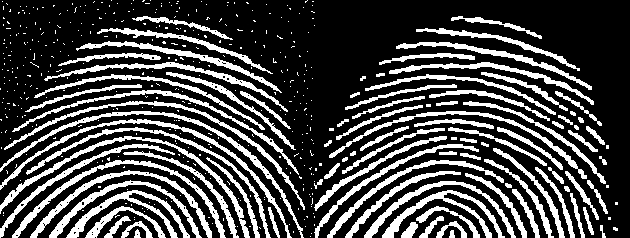

In [13]:
kernel = np.ones((3,3), np.uint8)


# Opening: 배경의 흰색 점(노이즈) 제거
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
# Closing: 끊어진 지문 선을 메우고 연결
result = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

cv2_imshow(np.hstack((img, result)))

Opening: 배경에 있는 작은 흰색 노이즈를 삭제하는 데 효과적이다
Closing: 지문 선 사이의 작은 구멍을 메우고 끊어진 선을 연결해서 형태를 매끄럽게 만든다.

#HW#2-6

In [14]:
img = cv2.imread('/content/Fig0905(a)(wirebond-mask).tif', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, dsize=(0,0), fx = 0.5, fy = 0.5)

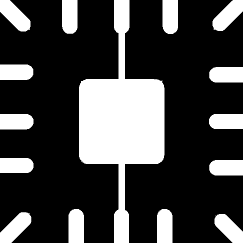

In [15]:
size = 5
morph = np.ones((size, size), np.uint8)
opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, morph, iterations=1)
cv2_imshow(opening)

Opening 연산은 객체의 전체적인 크기는 유지하면서, 커널보다 작은 얇은 선이나 돌출된 노이즈만 선택적으로 제거하는 데 사용된다.

그래서 사진의 결과처럼 얇은선만 선택적으로 제거 가능하다.

# HW#2-7

In [16]:
img = cv2.imread('Fig0939(a)(headCT-Vandy).tif', 0)
img = cv2.resize(img, (256, 256))

In [17]:
# Sobel: 1차 미분 기반 (가로/세로 합산)
dx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
dy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.convertScaleAbs(cv2.magnitude(dx, dy))

# Laplacian: 2차 미분 기반
laplacian = cv2.Laplacian(img, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)

# Canny
canny = cv2.Canny(img, 100, 200)

# Morphological Gradient: 팽창 - 침식
kernel = np.ones((3,3), np.uint8)
morph_grad = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)



원본 | Sobel | Laplacian


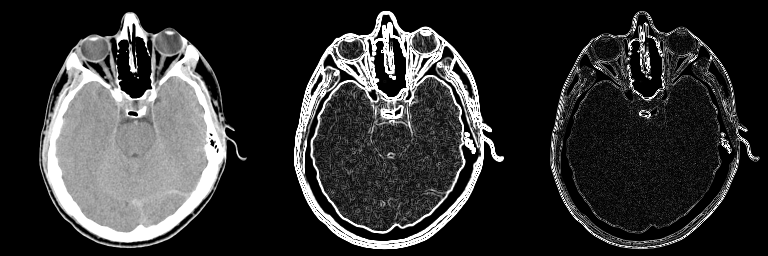

Canny | Morphological Gradient


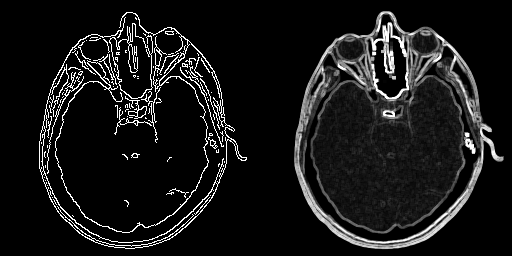

In [18]:
print("원본 | Sobel | Laplacian")
cv2_imshow(np.hstack((img, sobel, laplacian)))
print("Canny | Morphological Gradient")
cv2_imshow(np.hstack((canny, morph_grad)))

- sobel: 에지가 두껍게 나타나며, 노이즈에 강하다.
- Laplacian: 소벨보다 에지가 가늘게 나오지만 노이즈에 민감해서 영상이 지저분해 보일 수 있다
- Canny:: 에지가 모두 같은 두께로 만들어짐
- Morphological Gradient: 노이즈에 강하며, 객체의 경계면을 일정 두께로 감싸는 형태의 에지를 얻을 수 있음.

# HW#2-8

In [19]:
img = cv2.imread('Fig0938(a)(cygnusloop_Xray_original).tif', 0)
img = cv2.resize(img, (400, 400))



In [20]:
# Smoothing Filter: 평균값 기반
# 주변 픽셀들을 평균내어 뭉개버리는 방식
blur_img = cv2.blur(img, (5, 5))

# Morphological Smoothing (Opening -> Closing)
# 열기로 밝은 노이즈를 지우고, 닫기로 어두운 구멍을 메운다.
kernel = np.ones((5, 5), np.uint8)
opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
morph_smooth = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)


원본 영상 | Smoothing Filter (Box) | Morphological Smoothing


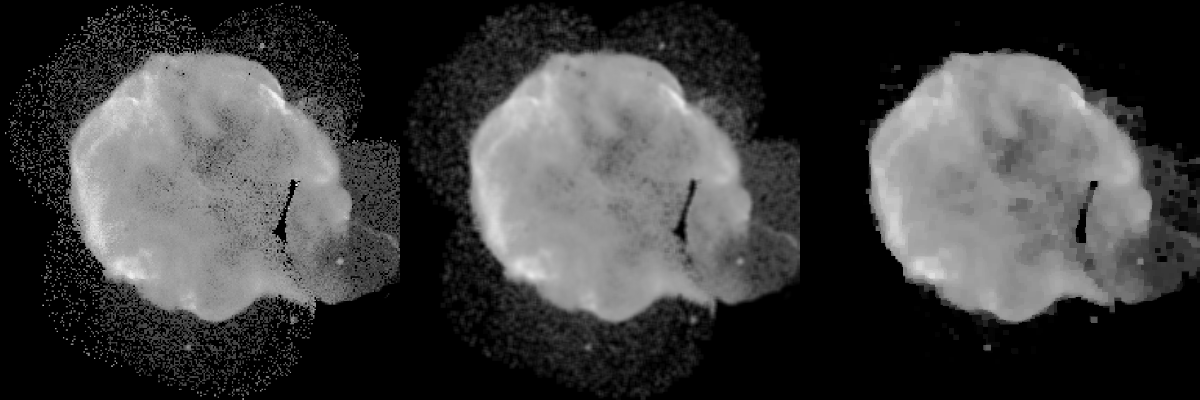

In [21]:
print("원본 영상 | Smoothing Filter (Box) | Morphological Smoothing")
cv2_imshow(np.hstack((img, blur_img, morph_smooth)))

- Smoothing Filter (평균값 필터): 노이즈가 지워지긴 하지만, 영상의 전체적인 선명도가 떨어지고 뿌옇게 변하는 단점 때문에 결과에서도 전체적으로 뿌옇게 보인다.

- Morphological Smoothing: 객체의 윤곽이나 밝기 강도를 잘 보존하면서 작은 노이즈만 선택적으로 제거한다. 원본 사진처럼 노이즈가 심할때 효과적이다.

# HW#2-9

In [22]:
img = cv2.imread('Fig0940(a)(rice_image_with_intensity_gradient).tif', 0)


In [23]:
# 오츄(Otsu) 전역 이진화
# 영상 전체에 하나의 임곗값 적용.
_, otsu_bin = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Top-hat 변환을 이용한 배경 보정 후 이진화
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (60, 60))
tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)
_, tophat_bin = cv2.threshold(tophat, 40, 255, cv2.THRESH_BINARY)


원본 영상 | 오츄 전역 이진화 | Top-hat 배경 보정 후 이진화


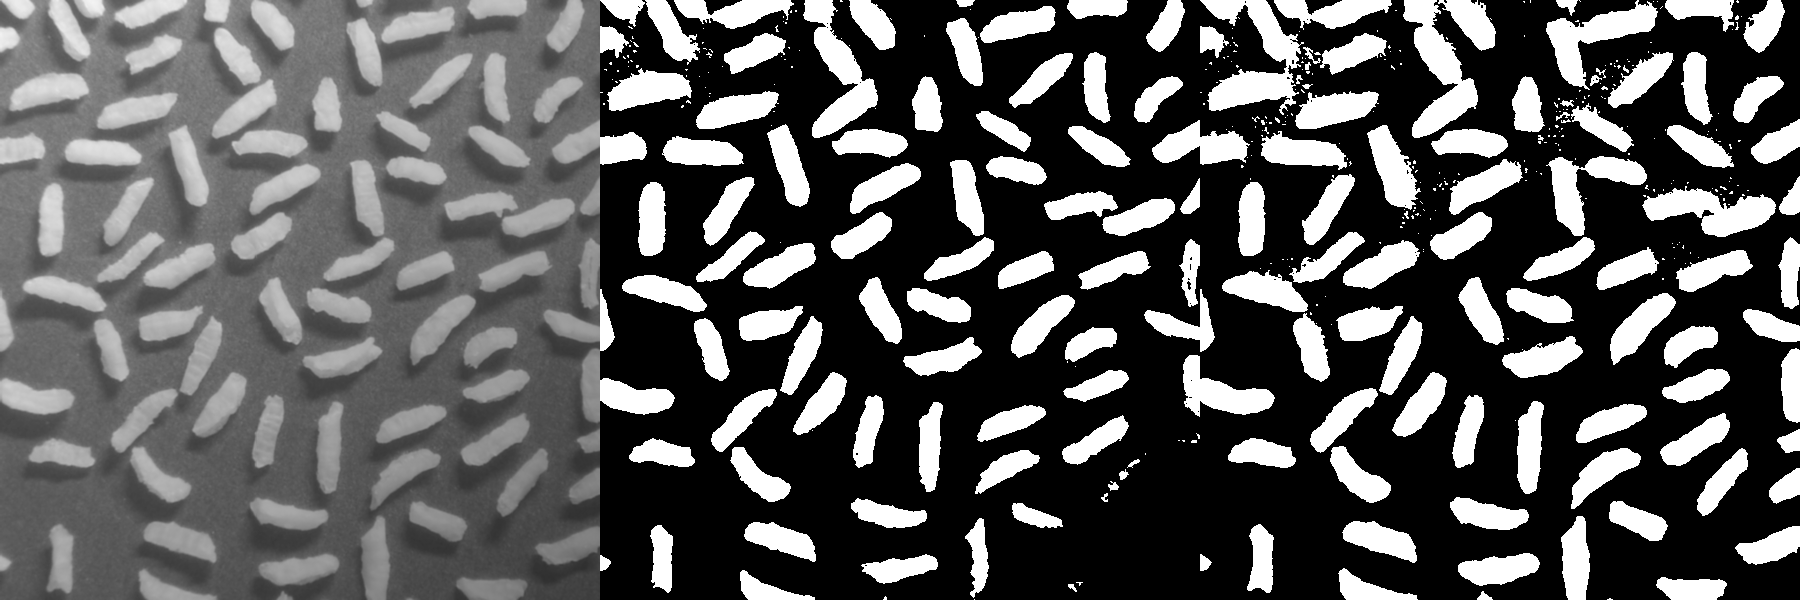

In [24]:
print("원본 영상 | 오츄 전역 이진화 | Top-hat 배경 보정 후 이진화")
cv2_imshow(np.hstack((img, otsu_bin, tophat_bin)))

- 오츄 전역 이진화: 원본처럼 조명이 불균일한 경우, 밝은 위쪽은 잘 나오지만 어두운 아래쪽 쌀알들은 배경으로 처리되어 사라지는 문제가 발생한다.

- Top-hat 변환 기반 이진화: 배경이 제거되어 영상 전체의 밝기가 평탄해졌기 때문에, 이진화 시 아래쪽의 쌀알들도 유실되지 않고 선명하게 추출된다.

# HW#2-10

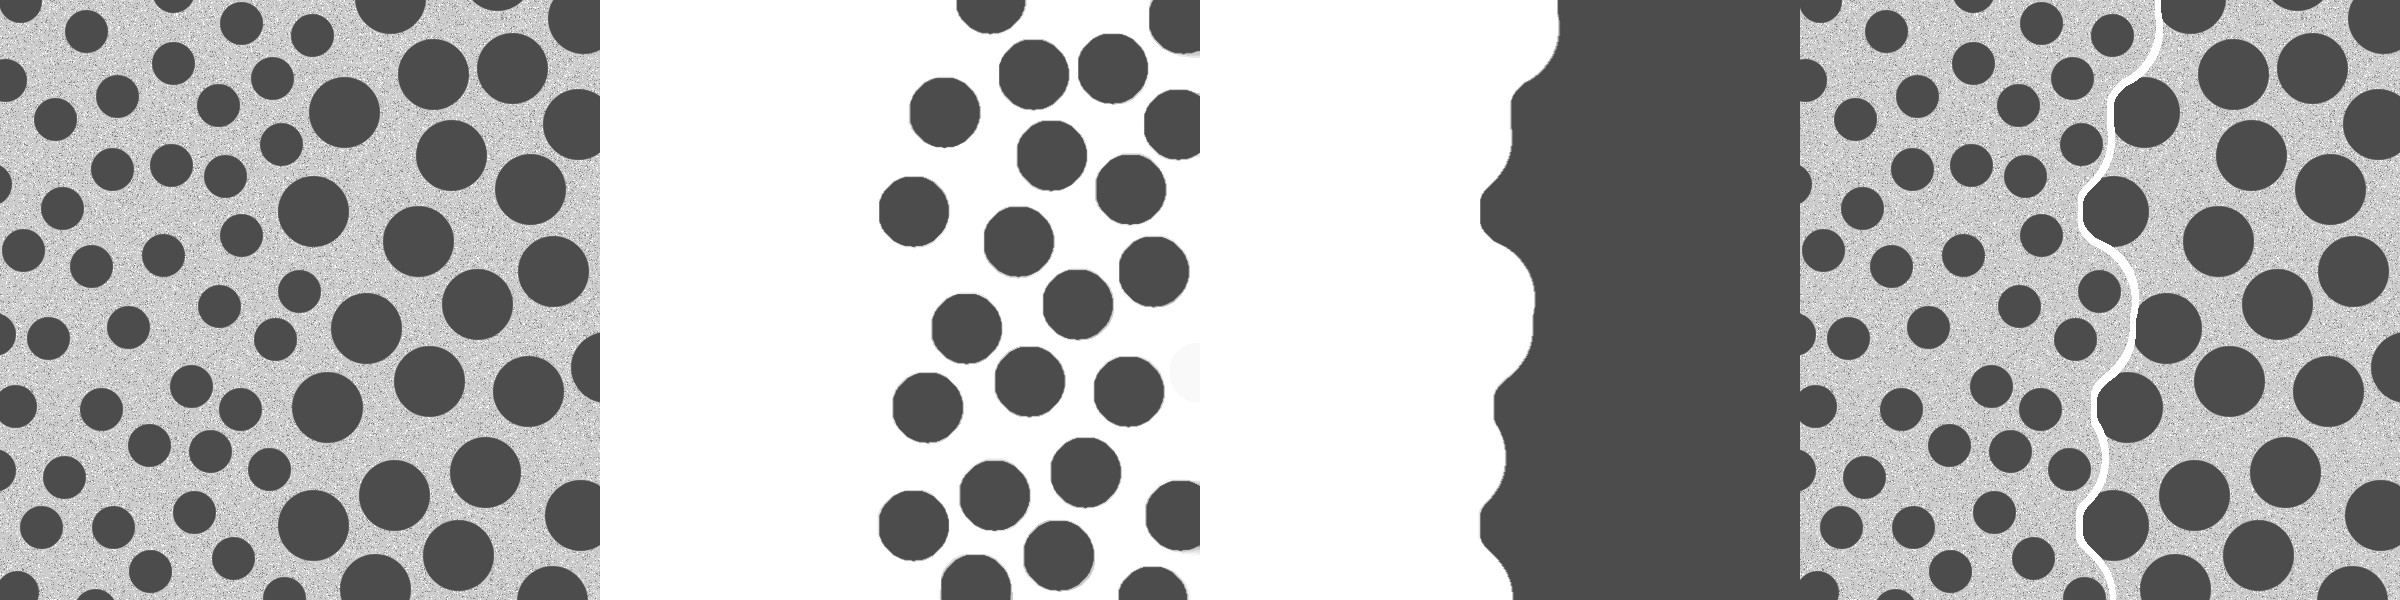

In [25]:
img10 = cv2.imread('/content/Fig0943(a)(dark_blobs_on_light_background).tif', cv2.IMREAD_GRAYSCALE)

# 1. 닫힘 연산
ksize_close = 60
kernel_30 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize_close, ksize_close))
closing_img10 = cv2.morphologyEx(img10, cv2.MORPH_CLOSE, kernel_30)

# 2. 열림 연산
ksize_open = 120
kernel_60 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize_open, ksize_open))
opening_img10 = cv2.morphologyEx(closing_img10, cv2.MORPH_OPEN, kernel_60)

# 3. 경계선 추출
ksize_grad = 5
kernel_grad = np.ones((ksize_grad, ksize_grad), np.uint8)
boundary_img10 = cv2.morphologyEx(opening_img10, cv2.MORPH_GRADIENT, kernel_grad)

# 4. 결과 합성 및 채널 맞추기

img10_color = cv2.cvtColor(img10, cv2.COLOR_GRAY2BGR)
closing_color = cv2.cvtColor(closing_img10, cv2.COLOR_GRAY2BGR)
opening_color = cv2.cvtColor(opening_img10, cv2.COLOR_GRAY2BGR)

final_result = img10_color.copy()
final_result[boundary_img10 != 0] = [255, 255, 255]

show_all = np.hstack((img10_color, closing_color, opening_color, final_result))
cv2_imshow(show_all)

Closing: 쌀알처럼 흩어져 있는 작은 객체들을 배경과 합쳐서 제거하는 과정이다. 그래서 작은 객체는 사라져있다.

Opening: 닫힘 연산으로 뭉쳐진 큰 객체들 사이의 미세한 밝은 영역을 지워, 완전한 하나의 영역으로 덩어리화하는 과정이다. 경계만 남게 되었다.

Morphological Gradient: 팽창 이미지에서 침식 이미지를 빼서 객체의 외곽선을 따내는 과정으로 경계선이 생겼다.